# Drake Systems Fundamentals

**Learning Objectives:**
1. Implement a custom `LeafSystem` from scratch
2. Understand Drake's block diagram systems framework
3. Build and wire block diagrams yourself
4. Write simulation code
5. Use Drake documentation and tutorials effectively

- 从头实现一个自定义的 LeafSystem
- 理解 Drake 的方块图（block diagram）系统框架
- 自己构建并连接方块图
- 编写仿真代码
- 有效使用 Drake 文档和教程

**What you'll implement:** You'll implement an inverted pendulum system from scratch, and simulate it using Drake's built-in simulation tools.

---


In [7]:
# before running the whole notebook, run this cell once to install dependencies!
# %pip install gradescope_utils
# %pip install timeout_decorator

## Setup and Imports

Let us first import Drake functionality. We will cover them as we go along, so don't worry about them for now. 

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from pydrake.all import (
    BasicVector,
    ConstantVectorSource,
    Context,
    ContinuousState,
    Diagram,
    DiagramBuilder,
    LeafSystem,
    LogVectorOutput,
    Simulator,
)
from pydrake.systems.drawing import plot_system_graphviz

from manipulation.exercises.grader import Grader
from manipulation.exercises.intro.test_intro_fundamentals import (
    TestIntroFundamentalsPendulumImplementation,
    TestIntroFundamentalsSimulationExercises,
)

---

## Part 1: Writing Your Own Dynamics

Drake models complex systems as **block diagrams** composed of simple building blocks. Each block is a `System` that:
- Has **input ports** (receives signals) 
- Has **output ports** (sends signals) 
- Maintains internal **state**
- Defines **dynamics** (how state evolves over time)

A `System` can be just a simple, single system, or it can be a collection of multiple smaller subsystems, for instance connected together in a `Diagram` (which we will learn more about in a second). For now, we will look only at a single custom system, which you will usually implement by inheriting from the Drake class `LeafSystem`. In this part of the notebook, you will implement your own simple physical system (an inverted pendulum) using `LeafSystem`. Later in the class and for the project you might find yourself inheriting from `LeafSystem` when you are writing custom controllers, estimators, sensors, etc!

Below you can see an example of a `Diagram` consisting of smaller subsystems: an inverted pendulum with a constant input source, which outputs to a logging system. In fact, this is the `Diagram` we will be building from scratch in this notebook!

<img src="https://raw.githubusercontent.com/RussTedrake/manipulation/refs/heads/master/book/figures/simple_inverted_pendulum_diagram.svg" width="1000">

**References:** To implement the tasks in this notebook, you will be referencing the official Drake tutorials. You don't have to read everything in them right now, we provide hints in the code pointing you towards the relevant sections. The tutorials we will be referencing are:
- [Dynamical Systems Tutorial](https://github.com/RobotLocomotion/drake/blob/master/tutorials/dynamical_systems.ipynb)
- [Authoring Leaf Systmes](https://github.com/RobotLocomotion/drake/blob/7abd7dc1a95387490e2d5fa23fe938f57eddecfc/tutorials/authoring_leaf_systems.ipynb)

If you are unsure about how to use a function, refer to the [Official Drake documentation](https://drake.mit.edu/pydrake/index.html). For example, the documentation for `DeclareVectorInputPort` and similar functions can be found [on this page](https://drake.mit.edu/pydrake/pydrake.systems.framework.html) which we found by searching for "DeclareVectorInputPort) and then by cmd+F for "DeclareVectorInputPort". 

(**A note on the Drake documentation:** There are two sets of documentation for Drake: one for Python and [one for C++](https://drake.mit.edu/doxygen_cxx/index.html). The C++ and Python APIs for Drake are the same, but the C++ documentation is usually a bit more detailed and easier to navigate than the Python documentation, so most users of Drake tend to prefer the C++ documentation. So as you get more familiar with Drake, you might want to check out the C++ documentation instead!)

**YOUR TASK:** Implement an inverted pendulum (with zero friction) as a custom `LeafSystem`
Here are the system specifications you will need:
- **State:** $x = [\theta, \dot{\theta}]$ (angle and angular velocity)
- **Input:** $u$ (torque applied at the base)  
- **Dynamics:** $\ddot{\theta} = -\frac{g}{l}\sin(\theta) + \frac{u}{ml^2}$
- **Output:** $y = \theta$ (just the angle)

In [9]:
# TODO: Implement your own InvertedPendulum class


class InvertedPendulum(LeafSystem):
    def __init__(
        self, mass: float = 1.0, length: float = 1.0, gravity: float = 9.81
    ) -> None:
        # HINT: Look at the Dynamical Systems Tutorial,
        #       section "Deriving from LeafSystem"
        # TODO: Call the parent constructor
        super().__init__()
        # TODO: Store the physical parameters as instance variables
        self.mass = mass
        self.length = length
        self.gravity = gravity

        # TODO: Declare continuous state for [theta, theta_dot]
        #       (note that we won't need the state_index they use in the tutorial,
        #        so you can disregard the return value)
        self.DeclareContinuousState(2)

        # HINT: Look at the Authoring Leaf Systems Tutorial,
        #       section "Vector-valued Ports"
        # TODO: Declare input port for torque
        torque_port = self.DeclareVectorInputPort(name="torque", size=1) # pyright: ignore[reportCallIssue]
        # TODO: Save the input port as an instance variable so we can
        #       access it in `DoCalcTimeDerivatives`
        self._torque_port = torque_port
        # TODO: Declare output port for **just** theta (not theta_dot)
        self.DeclareVectorOutputPort(name="theta", size=1, calc=self.OutputTheta) # type: ignore


    def DoCalcTimeDerivatives(
        self, context: Context, derivatives: ContinuousState
    ) -> None:
        # HINT: Look at the Dynamical Systems Tutorial,
        #       section "Deriving from LeafSystem"
        # TODO: Get current state from context (extract theta and theta_dot)
        theta = context.get_continuous_state_vector().GetAtIndex(0)
        theta_dot = context.get_continuous_state_vector().GetAtIndex(1)

        # HINT: Note that context.get_continuous_state_vector() returns a VectorBase
        #       object, which you can index into to get the theta and theta_dot using
        #       .GetAtIndex(), or simply context.get_continuous_state_vector()[index]
        #       or simply context.get_continuous_state_vector()[index]

        # HINT: Look at the Authoring Leaf Systems Tutorial,
        #       section "Vector-valued Ports"
        # TODO: Get input torque by evaluating the input port
        if self._torque_port.HasValue(context):
            torque = self._torque_port.Eval(context)[0]

        # HINT: Look at the Dynamical Systems Tutorial,
        #       section "Deriving from LeafSystem"
        # TODO: Compute pendulum dynamics
        theta_ddot = -(self.gravity / self.length) * np.sin(theta) + torque / (self.mass * self.length**2)
        # TODO: Set the derivatives [theta_dot, theta_ddot]
        # derivatives.get_mutable_vector().SetAtIndex(0, theta_dot)
        # derivatives.get_mutable_vector().SetAtIndex(1, theta_ddot)
        derivatives.get_mutable_vector().SetFromVector([theta_dot, theta_ddot]) # type: ignore
        # pass  # Remove this when you implement

    def OutputTheta(self, context: Context, output: BasicVector) -> None:
        # HINT: Look at the Authoring Leaf Systems Tutorial,
        #       section "Vector-valued Ports"
        # TODO: Get state from context, and extract theta (first element)
        theta = context.get_continuous_state_vector().GetAtIndex(0)
        # TODO: Set the output port to theta
        # output.SetAtIndex(0, theta) # type: ignore
        output.SetFromVector([theta]) # type: ignore


**When you are done, make sure to run the tests below to make sure everything is working as expected!**

In [10]:
Grader.grade_output(
    [TestIntroFundamentalsPendulumImplementation], [locals()], "results.json"
)
Grader.print_test_results("results.json")

Total score is 30/30.

Score for test_inverted_pendulum_structure (manipulation.exercises.intro.test_intro_fundamentals.TestIntroFundamentalsPendulumImplementation.test_inverted_pendulum_structure) is 10/10.

Score for test_pendulum_dynamics (manipulation.exercises.intro.test_intro_fundamentals.TestIntroFundamentalsPendulumImplementation.test_pendulum_dynamics) is 10/10.

Score for Test pendulum output computation is 10/10.


### System `Context`
In the code above, you probably noticed the use of something called the `context`. In Drake, the `context` contains all the dynamical information about your simulation and all the systems in it.

Please read the following tutorial section before proceeding:
- [Dynamical Systems Tutorial](https://github.com/RobotLocomotion/drake/blob/master/tutorials/dynamical_systems.ipynb): **The System "Context"**

Next, let us create a default context for our Pendulum, change it a bit, and have a look at it!

For this simple system, you see that the context only contains the current time, as well as the two states we defined for our system.

In [11]:
# TODO: Set the values for time and state to some reasonable values
time = 4.0
theta = 0.1
theta_dot = 0.2

# TODO: Uncomment the following lines:
pendulum = InvertedPendulum()
pendulum_context = pendulum.CreateDefaultContext()
pendulum_context.get_mutable_continuous_state().SetFromVector([theta, theta_dot]) # type: ignore
# pendulum_context.get_mutable_continuous_state_vector().SetFromVector([theta, theta_dot]) # type: ignore
pendulum_context.SetTime(time)
print(pendulum_context)

::_ Context
------------
Time: 4
States:
  2 continuous states
    0.1 0.2




--- 
## Part 2: Connecting Systems in a Diagram

In this part, you will create a complete `Diagram` that we will later use for simulation by connecting multiple Drake `System`s together:
1. **InvertedPendulum** - your dynamical system
2. **ConstantVectorSource** - provides constant torque input  
3. **LogVectorOutput** - records output data over time

**YOUR TASK:** Build a `Diagram` for simulation of the inverted pendulum, where the pendulum is provided with a constant input torque, and we log the outputs.

**References:** In this part, we will only be referencing this tutorial (we will keep pointing you towards the relevant sections in the code):
- [Dynamical Systems Tutorial](https://github.com/RobotLocomotion/drake/blob/master/tutorials/dynamical_systems.ipynb): section **"Simulation"** and **"Combinations of Systems: Diagram and DiagramBuilder"**

In [12]:
# TODO: Implement the diagram builder function


def build_pendulum_diagram(
    input_torque: float = 0.0,
) -> tuple[Diagram, InvertedPendulum, LogVectorOutput]: # type: ignore

    # HINT: Look at the Dynamical Systems Tutorial, section "Simulation"
    # TODO: Create a DiagramBuilder
    builder = DiagramBuilder()
    # TODO: Add your inverted pendulum system to the builder
    pendulum = builder.AddNamedSystem("pendulum", InvertedPendulum())
    # TODO: Add a constant torque source
    # HINT: This is not in the tutorial, so we have provided the code for you.
    # torque_source = ConstantVectorSource(np.array([input_torque]))
    torque_source = builder.AddNamedSystem("torque_source", ConstantVectorSource(np.array([input_torque])))


    # TODO: Add data logging system
    logger = LogVectorOutput(pendulum.get_output_port(0), builder)
    logger.set_name("logger")
    # TODO: Connect the systems together
    builder.Connect(torque_source.get_output_port(0), pendulum.get_input_port(0))

    # HINT: Look at the Dynamical Systems Tutorial, section
    #       "Combinations of Systems: Diagram and DiagramBuilder"
    # HINT: The constant torque source should be connected to the pendulum's input port,
    #       but the LogVectorOutput is already connected to the pendulum's output port.
    builder.ExportOutput(pendulum.get_output_port(0))
    # TODO: Build and return the final diagram, system, and logger
    diagram = builder.Build()
    diagram.set_name("diagram")
    # Visualize the diagram.
    # plot_system_graphviz(diagram)

    return diagram, pendulum, logger  # type: ignore # Remove this when you implement


# TODO: Uncomment the following line:
diagram, pendulum, logger = build_pendulum_diagram(input_torque=0.1)

**Next, we will visualize the block diagram.**

Drake can automatically generate graphical representations of your block diagrams, which can be very helpful for understanding the system connections and debug wiring issues.

Run the code below to visualize your diagram:

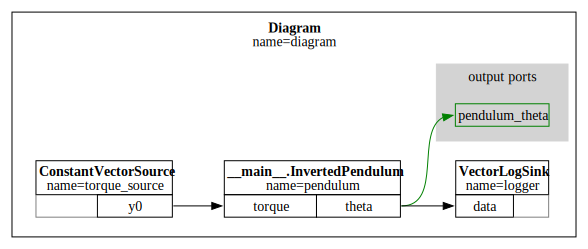

In [13]:
diagram, pendulum, logger = build_pendulum_diagram(input_torque=0.1)
plot_system_graphviz(diagram)

After visualizing, make sure to have a look at the diagram. Are the connections and the number of ports as you would expect?

Let us also have a look at the Diagram context (notice how it includes the pendulum context from earlier!):

In [14]:
# TODO: Uncomment the following line:
diagram, pendulum, logger = build_pendulum_diagram(input_torque=0.1)

# TODO: Create a context for the diagram
diagram_context = diagram.CreateDefaultContext()

# TODO: Print the context for the diagram
print(diagram_context)

::diagram Context (of a Diagram)
---------------------------------
2 total continuous states
1 total numeric parameters in 1 groups

::diagram::pendulum Context
----------------------------
Time: 0
States:
  2 continuous states
    0 0


::diagram::torque_source Context
---------------------------------
Time: 0
Parameters:
  1 numeric parameter groups with
     1 parameters
       0.1



**TIP:** This is not in the tutorial, but will be **very** useful soon in the class and for your project: 

If you ever want to get the context of a specific system from the entire diagram context, use the method:

`system.GetMyContextFromRoot(diagram_context)`.

Try it below for the inverted pendulum, and notice how we get back the simple pendulum context we printed earlier!


In [15]:
# TODO: Get the context of the pendulum from the diagram context
# pendulum_context = pendulum.GetMyContextFromRoot(diagram_context)
pendulum_context = pendulum.CreateDefaultContext()

# TODO: Print the pendulum context
print(pendulum_context)

::pendulum Context
-------------------
Time: 0
States:
  2 continuous states
    0 0




## Part 3: Simulation
In this part, we will finally put everything together and run the full simulation of our pendulum.

**YOUR TASK:** Implement the full simulation for your inverted pendulum system.

**References:** In this part, we will only be referencing this tutorial (we will keep pointing you towards the relevant sections in the code):
- [Dynamical Systems Tutorial](https://github.com/RobotLocomotion/drake/blob/master/tutorials/dynamical_systems.ipynb): section **"Simulation"**

In [16]:
# TODO: Implement the simulation function


def simulate_pendulum(
    initial_state: np.ndarray, simulation_time: float = 5.0, torque: float = 0.0
) -> tuple[np.ndarray, np.ndarray]:
    # TODO: Build your diagram using the function you implemented
    diagram, pendulum, logger = build_pendulum_diagram(input_torque=torque)

    # HINT: Look at the Dynamical Systems Tutorial, section "Simulation"
    # TODO: Create a context for the diagram
    diagram_context = diagram.CreateDefaultContext()
    
    # TODO: Create a simulator for the diagram with the context
    simulator = Simulator(diagram, diagram_context)

    # TODO: Set initial conditions for the pendulum
    pendulum_context = pendulum.GetMyContextFromRoot(diagram_context)
    # pendulum_context = diagram.GetMutableSubsystemContext(pendulum, diagram_context)
    pendulum_context.get_mutable_continuous_state_vector().SetFromVector(initial_state)

    # TODO: Run the simulation to the specified time
    simulator.AdvanceTo(simulation_time)

    # TODO: Extract the logged data from the logger
    log = logger.FindLog(simulator.get_context())

    # TODO: Return the time and state data from the log
    time = log.sample_times()
    state = log.data()

    return time, state
    # return np.array([]), np.array([])  # Remove this when you implement

When you are done, let us run the code below to test the implementation. We will check that the pendulum swings past the downright equilibrium point, and also do some visualization so you can see what is happening!

Simulation complete! Recorded 407 timesteps
Initial angle: 0.5000 rad (28.6°)
Final angle: 0.4177 rad (23.9°)
✅ Physics check PASSED - pendulum oscillated as expected
Let us plot the angle over time (notice how there is no friction, hence the pendulum swings indefinitely!):


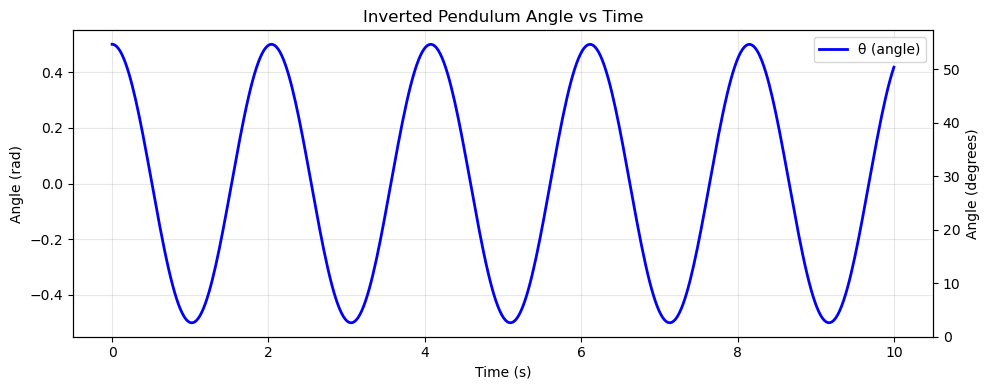

In [17]:
# Test your implementation (you do not need to modify this code)
initial_state = [0.5, 0.0]  # small angle, zero velocity
times, outputs = simulate_pendulum(initial_state, simulation_time=10.0, torque=0.0) # type: ignore

print(f"Simulation complete! Recorded {len(times)} timesteps")
print(f"Initial angle: {outputs[0, 0]:.4f} rad ({np.degrees(outputs[0, 0]):.1f}°)")
print(f"Final angle: {outputs[0, -1]:.4f} rad ({np.degrees(outputs[0, -1]):.1f}°)")

# Check if pendulum swung past the equilibrium point
min_angle = np.min(np.abs(outputs[0, :]))
if np.isclose(min_angle, 0.0, atol=1e-3):
    print("✅ Physics check PASSED - pendulum oscillated as expected")
else:
    print("❌ Physics check FAILED - pendulum didn't swing properly")

print(
    "Let us plot the angle over time (notice how there is no friction, hence the pendulum swings indefinitely!):"
)
# Plot the angle over time
plt.figure(figsize=(10, 4))
plt.plot(times, outputs[0, :], "b-", linewidth=2, label="θ (angle)")
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.title("Inverted Pendulum Angle vs Time")
plt.grid(True, alpha=0.3)
plt.legend()

# Add degree labels on right y-axis
ax2 = plt.gca().twinx()
ax2.set_ylabel("Angle (degrees)")
ax2.set_ylim(np.degrees(plt.gca().get_ylim()[0]), np.degrees(plt.gca().get_ylim()[1]))

plt.tight_layout()
plt.show()

---

# VERIFICATION IN GRADESCOPE 

**Prerequisites:** You must complete ALL the TODOs above before these verification exercises will work!

**Instructions:** Implement the exercises below. Copy the exact numerical values (to 4 decimal places) for your verification keys, which you can copy/paste to Gradescope.



## Verification 1: Basic Simulation

**Task:** Simulate the inverted pendulum with:
- Initial state: θ = 0.15 rad, θ̇ = 0.0 rad/s  
- No applied torque (torque = 0.0)
- Simulation time: 2.5 seconds

**Question:** What is the angle θ at t = 2.5 seconds? (Report to 4 decimal places)


Simulation complete! Recorded 76 timesteps
Initial angle: 0.1500 rad (8.5944°)
Final angle: 0.0052 rad (0.2983°)
❌ Physics check FAILED - pendulum didn't swing properly
Let us plot the angle over time (notice how there is no friction, hence the pendulum swings indefinitely!):


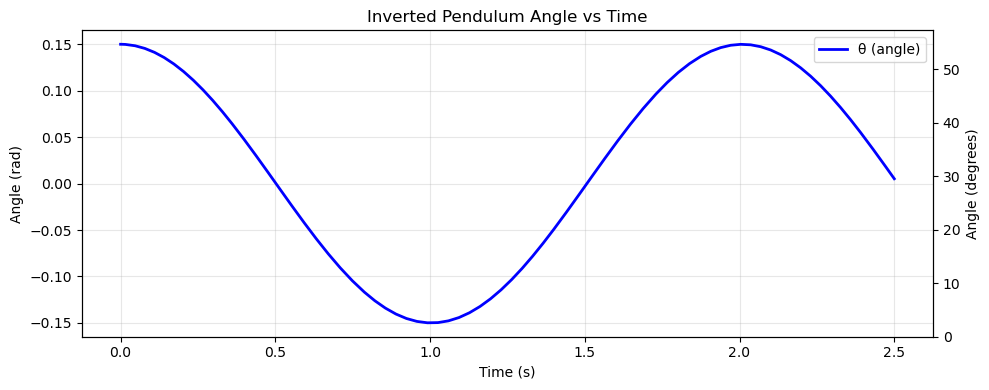

In [18]:
# TODO: Implement the simulation exercise
initial_state = [0.15, 0.0]
times, outputs = simulate_pendulum(initial_state, simulation_time=2.5, torque=0.0) # type: ignore

print(f"Simulation complete! Recorded {len(times)} timesteps")
print(f"Initial angle: {outputs[0, 0]:.4f} rad ({np.degrees(outputs[0, 0]):.4f}°)")
print(f"Final angle: {outputs[0, -1]:.4f} rad ({np.degrees(outputs[0, -1]):.4f}°)")

# Check if pendulum swung past the equilibrium point
min_angle = np.min(np.abs(outputs[0, :]))
if np.isclose(min_angle, 0.0, atol=1e-3):
    print("✅ Physics check PASSED - pendulum oscillated as expected")
else:
    print("❌ Physics check FAILED - pendulum didn't swing properly")

print(
    "Let us plot the angle over time (notice how there is no friction, hence the pendulum swings indefinitely!):"
)
# Plot the angle over time
plt.figure(figsize=(10, 4))
plt.plot(times, outputs[0, :], "b-", linewidth=2, label="θ (angle)")
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.title("Inverted Pendulum Angle vs Time")
plt.grid(True, alpha=0.3)
plt.legend()

# Add degree labels on right y-axis
ax2 = plt.gca().twinx()
ax2.set_ylabel("Angle (degrees)")
ax2.set_ylim(np.degrees(plt.gca().get_ylim()[0]), np.degrees(plt.gca().get_ylim()[1]))

plt.tight_layout()
plt.show()

## Verification 2: With Applied Torque

**Task:** Simulate the pendulum with:
- Initial state: θ = -0.1 rad, θ̇ = 0.2 rad/s
- Constant applied torque: 0.5 N⋅m
- Simulation time: 1.8 seconds

**Question:** What is the angle θ at t = 1.8 seconds? (Report to 4 decimal places)


Simulation complete! Recorded 56 timesteps
Initial angle: -0.1000 rad (-5.7296°)
Final angle: -0.1074 rad (-6.1555°)
✅ Physics check PASSED - pendulum oscillated as expected
Let us plot the angle over time (notice how there is no friction, hence the pendulum swings indefinitely!):


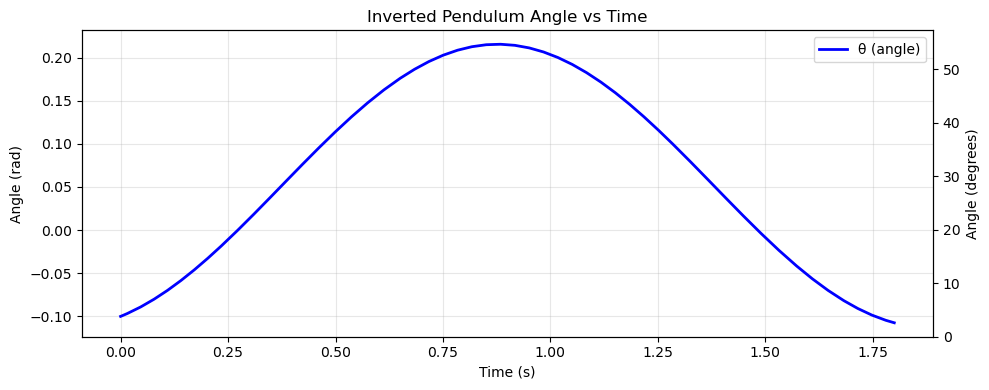

In [19]:
# TODO: Implement the simulation exercise
# TODO: Implement the simulation exercise
initial_state = [-0.1, 0.2]
times, outputs = simulate_pendulum(initial_state, simulation_time=1.8, torque=0.5) # type: ignore

print(f"Simulation complete! Recorded {len(times)} timesteps")
print(f"Initial angle: {outputs[0, 0]:.4f} rad ({np.degrees(outputs[0, 0]):.4f}°)")
print(f"Final angle: {outputs[0, -1]:.4f} rad ({np.degrees(outputs[0, -1]):.4f}°)")

# Check if pendulum swung past the equilibrium point
min_angle = np.min(np.abs(outputs[0, :]))
if np.isclose(min_angle, 0.0, atol=1e-3):
    print("✅ Physics check PASSED - pendulum oscillated as expected")
else:
    print("❌ Physics check FAILED - pendulum didn't swing properly")

print(
    "Let us plot the angle over time (notice how there is no friction, hence the pendulum swings indefinitely!):"
)
# Plot the angle over time
plt.figure(figsize=(10, 4))
plt.plot(times, outputs[0, :], "b-", linewidth=2, label="θ (angle)")
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.title("Inverted Pendulum Angle vs Time")
plt.grid(True, alpha=0.3)
plt.legend()

# Add degree labels on right y-axis
ax2 = plt.gca().twinx()
ax2.set_ylabel("Angle (degrees)")
ax2.set_ylim(np.degrees(plt.gca().get_ylim()[0]), np.degrees(plt.gca().get_ylim()[1]))

plt.tight_layout()
plt.show()

---

# Congratulations!

You've successfully completed **Drake Systems Fundamentals**! You've learned:

1. **LeafSystem** is the base class for most custom Drake systems
3. **Context** holds the state, time, and parameters for simulation
2. **DiagramBuilder** connects systems into larger compositions (`Diagram`s)
4. **Drake documentation** and **Drake tutorials** are your best friends - use them!

**Next:** In Notebook 2, you'll work with real robots using `MultibodyPlant` and create your own custom assets!


## 额外练习：离散时间系统实现

我为你设计了一个**简单却有教育意义的题目**：实现一个离散时间的**一维粒子运动模拟器**（1D Particle in a Force Field）。这个题目结合了基本物理（位置和速度的离散更新）和控制（可选添加输入力），适合初学者逐步构建。它与机器人相关（类似于简化版的机械臂关节动力学），但不复杂。你可以用 Python 实现，逐步添加功能。如果完成这个，你可以扩展到更复杂的系统如离散 PID 控制器或倒立摆。

下面是题目的详细描述，包括背景、要求、步骤指导和参考代码框架。慢慢来，按照步骤实现；如果卡住，贴你的代码或错误，我帮你调试！

#### 题目背景
- **问题描述**：模拟一个一维粒子（particle）在力场中的运动。粒子有位置 \( x \) 和速度 \( v \)，受外部输入力 \( u \)（control input）和恒定重力 \( g = -9.8 \) m/s² 影响。
- **离散模型**：使用 Euler 前向积分（forward Euler）离散化连续动力学：
  - 连续形式： \( \dot{x} = v \), \( \dot{v} = u + g \)。
  - 离散形式（时间步 \( \Delta t = 0.01 \) s）： \( x[k+1] = x[k] + v[k] \Delta t \), \( v[k+1] = v[k] + (u[k] + g) \Delta t \)。
- **目标**：用 Drake 自定义一个离散 `LeafSystem`，模拟粒子的状态演化。添加输入端口（u）和输出端口（x, v），然后构建 diagram 并运行模拟。最终可视化轨迹（e.g., 用 Matplotlib 画位置 vs 时间）。

- **为什么这个题目适合**？
  - 简单：只需基本线性代数和离散更新。
  - 教育性：练习 Drake 的系统构建、状态声明、端口和模拟。
  - 扩展性：完成后，你可以添加噪声、控制器（e.g., 使粒子跟踪目标位置），或整合到 MultibodyPlant（e.g., 模拟机械臂关节）。

#### 要求
- **输入**：一个 scalar 输入端口（u：外部力，double 类型）。
- **输出**：一个 vector 输出端口（[x, v]：位置和速度，BasicVector(2)）。
- **状态**：离散状态向量（[x, v]，初始化为 [0, 0]）。
- **模拟**：运行 10 秒，应用正弦波输入力 \( u(t) = \sin(2\pi t) \)，记录轨迹并 plot。
- **约束**：用 Python 接口；时间步固定为 0.01 s；无连续状态（纯离散系统）。
- **bonus**（可选扩展）：添加随机噪声到速度更新，模拟不确定性。

#### 实现步骤（逐步指导）
1. **安装/导入**：确保有 Drake（pip install drake）。导入必要模块：
   ```python
   import numpy as np
   from pydrake.systems.framework import LeafSystem, BasicVector, DiagramBuilder
   from pydrake.systems.primitives import ConstantVectorSource
   from pydrake.simulation import Simulator
   import matplotlib.pyplot as plt
   ```

2. **定义自定义离散系统类**：
   - 继承 `LeafSystem`。
   - 在 `__init__` 中：声明离散状态（AbstractState 或 NumericState）、输入端口（DeclareVectorInputPort）和输出端口（DeclareVectorOutputPort）。
   - 重写 `DoCalcDiscreteVariableUpdates`：计算下一状态（x[k+1], v[k+1]）。
   - 重写 `DoCalcVectorOutput`：输出当前 [x, v]。

3. **构建 Diagram**：
   - 用 DiagramBuilder 添加你的系统和一个输入源（e.g., ConstantVectorSource 或自定义 sin 输入）。
   - 连接端口。

4. **运行模拟**：
   - 创建 Simulator，设置初始状态，AdvanceTo(10.0)。
   - 记录输出轨迹。

5. **可视化**：用 plt 画 x(t) 和 v(t)。

#### 参考代码框架（填空式，供你完成）
```python
class DiscreteParticleSystem(LeafSystem):
    def __init__(self, dt=0.01, g=-9.8):
        super().__init__()
        self.dt = dt
        self.g = g
        
        # TODO: 声明离散状态（vector [x, v]，初始 [0, 0]）
        self.state_index = self.DeclareDiscreteState(2)  # 提示：DeclareDiscreteState(2) 返回索引
        
        # TODO: 声明输入端口（scalar u）
        self.DeclareVectorInputPort("u", BasicVector(1))  # 提示：大小1
        
        # TODO: 声明输出端口（vector [x, v]）
        self.DeclareVectorOutputPort("state", BasicVector(2), self.DoCalcVectorOutput)  # 提示：绑定 DoCalcVectorOutput
        
        # TODO: 声明离散更新事件（每 dt 秒更新一次）
        self.DeclarePeriodicDiscreteUpdateEvent(period_sec=dt, offset_sec=0.0, update=self.DoCalcDiscreteVariableUpdates)

    def DoCalcDiscreteVariableUpdates(self, context, events, discrete_state):
        # 获取当前状态和输入
        current_state = context.get_discrete_state(self.state_index).value()  # [x, v]
        u = self.get_input_port(0).Eval(context)[0]  # scalar u
        
        # TODO: 计算下一状态
        x_next = current_state[0] + current_state[1] * self.dt  # x[k+1] = x[k] + v[k] * dt
        v_next = ...  # 完成：v[k+1] = v[k] + (u + g) * dt
        
        # 更新 discrete_state
        discrete_state.get_mutable_vector(self.state_index).SetFromVector([x_next, v_next])

    def DoCalcVectorOutput(self, context, unused, state, output):
        # TODO: 输出当前 [x, v]
        current_state = context.get_discrete_state(self.state_index).value()
        output.SetFromVector(current_state)  # 设置输出

def run_simulation():
    builder = DiagramBuilder()
    
    # 添加你的系统
    particle = builder.AddSystem(DiscreteParticleSystem(dt=0.01))
    
    # TODO: 添加输入源（e.g., sin wave；用 ConstantVectorSource 或自定义系统）
    # 提示：对于 sin(t)，你可以自定义另一个 LeafSystem 输出 sin(2*pi*t)
    input_source = builder.AddSystem(ConstantVectorSource(np.array([0.0])))  # 先用常量0，bonus 改 sin
    
    # 连接
    builder.Connect(input_source.get_output_port(0), particle.GetInputPort("u"))
    
    # 构建 diagram
    diagram = builder.Build()
    
    # 创建 simulator
    simulator = Simulator(diagram)
    context = simulator.get_mutable_context()
    
    # TODO: 设置初始状态（e.g., [0, 10]）
    # 提示：context.SetDiscreteState(particle.state_index, np.array([0.0, 10.0]))
    
    # 运行模拟并记录轨迹
    times = []
    states = []
    simulator.Initialize()
    for t in np.arange(0.0, 10.0, 0.01):
        simulator.AdvanceTo(t)
        state = particle.GetOutputPort("state").Eval(context.get_mutable_subcontext_by_system(particle))
        times.append(t)
        states.append(state)
    
    # TODO: plot 轨迹
    states = np.array(states)
    plt.plot(times, states[:, 0], label='Position x')
    plt.plot(times, states[:, 1], label='Velocity v')
    plt.xlabel('Time (s)')
    plt.ylabel('State')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    run_simulation()
```

#### 预期输出和验证
- 运行后，如果输入 u=0，粒子应在重力下加速下落（x 减小，v 向负）。
- Plot：位置 x(t) 应是抛物线（自由落体），速度 v(t) 线性下降。
- **调试提示**：如果模拟不更新，检查事件声明；如果端口错，用 `diagram.GetInputPortNames()` 检查。

#### Bonus 扩展（完成后试试）
- **添加 sin 输入**：自定义一个 `SinInputSystem` 类，输出 \( \sin(2\pi t) \)（用 `DoCalcVectorOutput` 访问 context.time）。
- **噪声**：在 v_next 中加 np.random.normal(0, 0.1)。
- **控制器**：添加 PID 使 x 跟踪目标（如 5.0 m）。
- **整合机器人**：用 MultibodyPlant 添加一个 slider 关节，连接你的离散系统作为控制器。

这个题目难度适中，预计 1-2 小时完成。实现后，分享你的代码或结果，我们讨论优化！慢慢来，没问题！